In [6]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd

In [7]:
iris = load_iris()

In [8]:
X = iris.data
y = iris.target

<Axes: >

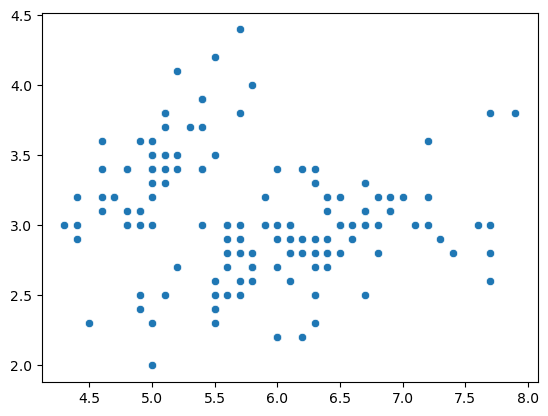

In [9]:
#visualize 
sns.scatterplot(x=X[:,0],y=X[:,1])

In [10]:
#visualize 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components= 2)

X_pca = pca.fit_transform(X_scaled)

In [12]:
wcss = []
for k in range(1, 10):
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_pca)
  wcss.append(kmeans.inertia_)

D:\Users\PARSHV\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Users\PARSHV\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Users\PARSHV\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Users\PARSHV\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

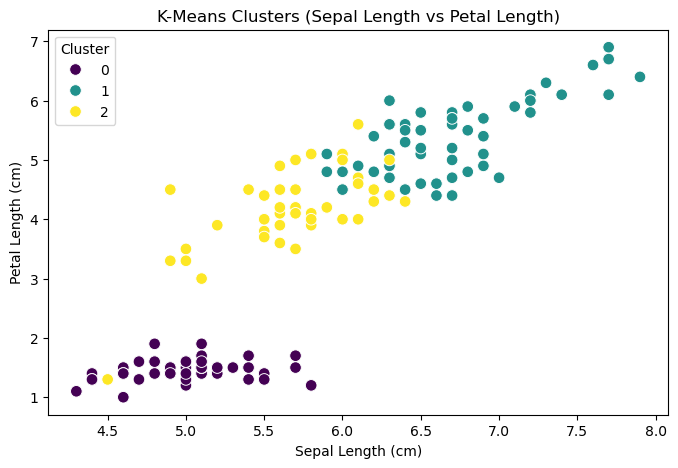

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score

# Cleaned Visualization
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=X[:, 0],
    y=X[:, 2],
    hue=labels,
    palette='viridis',
    s=70,
)
plt.title('K-Means Clusters (Sepal Length vs Petal Length)')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.legend(title='Cluster')
plt.show()

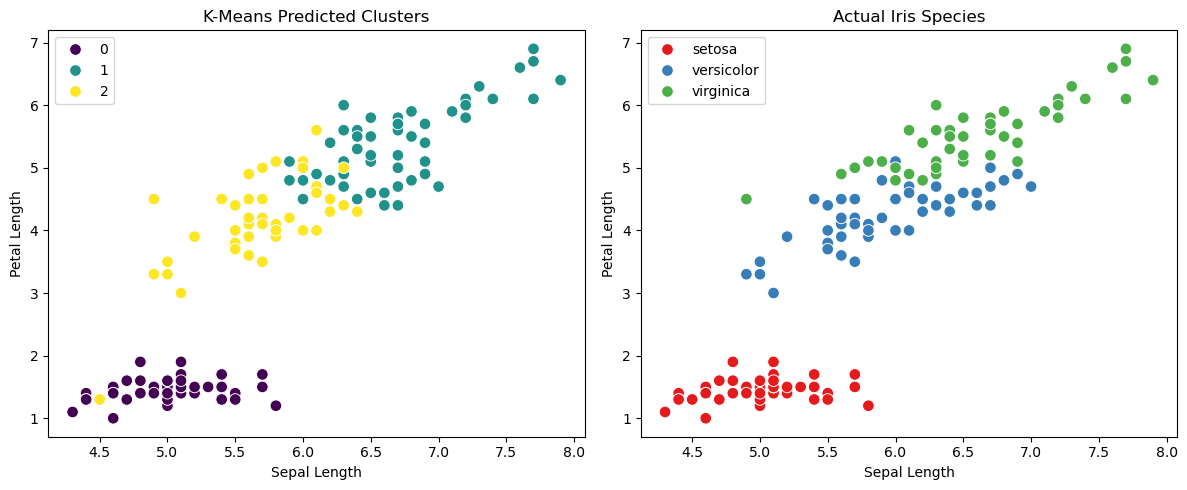

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graph A: K-Means Clusters
sns.scatterplot(
    ax=axes[0],
    x=X[:, 0],
    y=X[:, 2],
    hue=labels,
    palette='viridis',
    s=70,
)
axes[0].set_title('K-Means Predicted Clusters')
axes[0].set_xlabel('Sepal Length')
axes[0].set_ylabel('Petal Length')

# Graph B: Actual Iris Species
sns.scatterplot(
    ax=axes[1],
    x=X[:, 0],
    y=X[:, 2],
    hue=iris.target_names[y],
    palette='Set1',
    s=70,
)
axes[1].set_title('Actual Iris Species')
axes[1].set_xlabel('Sepal Length')
axes[1].set_ylabel('Petal Length')

plt.tight_layout()
plt.show()

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)


In [19]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [20]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [21]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)

GaussianNB()

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {'Logistic Regression': lr, 'KNN': knn, 'Naive Bayes': nb}

for name, model in models.items():
    y_pred = model.predict(X)
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y, y_pred))
    
    print("cm:", confusion_matrix(y, y_pred))

    print("classification report:", classification_report(y, y_pred))


Logistic Regression
Accuracy: 0.96
cm: [[50  0  0]
 [ 0 47  3]
 [ 0  3 47]]
classification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.94      0.94      0.94        50
           2       0.94      0.94      0.94        50

    accuracy                           0.96       150
   macro avg       0.96      0.96      0.96       150
weighted avg       0.96      0.96      0.96       150


KNN
Accuracy: 0.9533333333333334
cm: [[50  0  0]
 [ 0 50  0]
 [ 0  7 43]]
classification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.88      1.00      0.93        50
           2       1.00      0.86      0.92        50

    accuracy                           0.95       150
   macro avg       0.96      0.95      0.95       150
weighted avg       0.96      0.95      0.95       150


Naive Bayes
Accuracy: 0.953333333333333